## Actividad Final
### Regresión Lineal Simple

### Problema
Construir un modelo que haga predicciones de ventas basado en la invesión financiera de diferentes plataformas de publicidad.

### Datos
Utiliza el conjunto de datos CSV del archivo advertising.csv y analiza la relacion que tienen las diferentes plataformas respecto a las ventas.

### Leyendo y entendiendo los datos

In [1]:
# Importa pandas y numpy
import pandas as pd
import numpy as np

# Importa scikit-learn y métricas
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Importa librerías para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga el archivo CSV a una dataframe (DF) y visualiza los primeros
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
# Visualiza la dimensión del DF
df.shape

(200, 4)

In [4]:
# Visualiza la información del DF
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
# Visualiza las estadísticas generales del DF
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


### Limpiando los datos

In [6]:
# Busca si existen valores nulos en el DF. Utiliza le método isnull() con la función de agregación sum() 
# para saber la cantidad de nulos por cada variable del DF
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

#### Contesta en esta misma celda: ¿Cuál es tu opinión de acuerdo a los resultados anteriores, para realizar la limpieza de datos?

no se encontraron valores nulos en el DataFrame, por lo que no es necesario realizar un proceso de limpieza de datos en este aspect

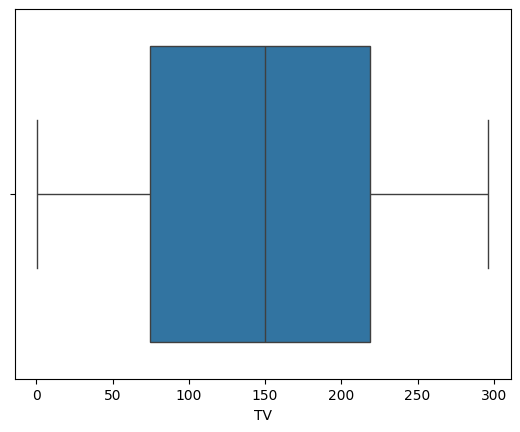

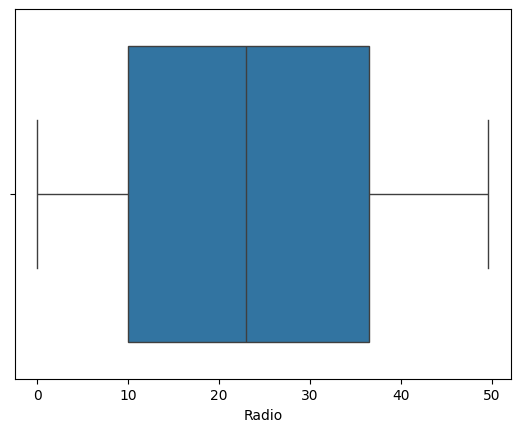

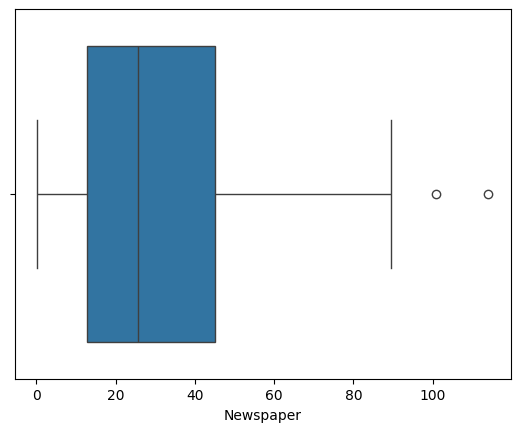

In [7]:
# Identifica si existen valor atípicos (outliers) en las 3 variables independientes que se estan estudiando. Utilza seaborn
# para realizar las gráficas de caja
sns.boxplot(x=df['TV'])
plt.show()

sns.boxplot(x=df['Radio'])
plt.show()

sns.boxplot(x=df['Newspaper'])
plt.show()

#### Contesta en esta misma celda: ¿Existen valores atípicos que realmente afecten el desempeño del entrenamiento? ¿Cómo procederías de acuerdo a tu respuesta anterior?

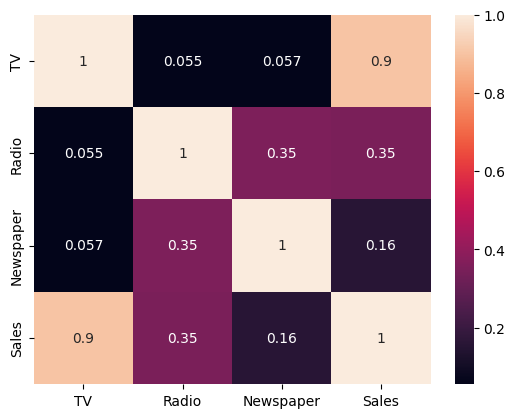

In [8]:
# Crear un mapa de calor (heatmap) para visualizar la correlación entre las variables independietes y dependiente
# Utiliza seaborn para graficar
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()


#### Contesta en esta misma celda: ¿Cuál es la variable que tiene mayor relación con las ventas?. 

## Constuyendo el modelo

### Importa las librerias sklearn para el split de los datos y el modelo de regesión lineal

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# Crea los conjutnos X y Y para le modelo de regresión lineal simple. Te recomiendo que uses la siguiente nomenclatura 
# Y = df['Sales']
x = df[['TV']]

Y = df['Sales']

In [11]:

x = x.values.reshape(-1, 1)

X_train, X_test, Y_train, Y_test = train_test_split(x, Y, test_size=0.2, random_state=42)

In [12]:
# Instancia el modelo LienarRegression()
modelo =  LinearRegression()
# Entrnea el modelo con el método fit y los conjutnos de entrenamiento (x_train, y_train)
modelo.fit(X_train, Y_train)
# Imprime la pendiente, bias y coeficientes resultados del entrenamiento
print('Pendiente:', modelo.coef_)
print('Bias:', modelo.intercept_)

Pendiente: [0.05548294]
Bias: 7.007108428241848


### Visualiza el desempeño del entrenamiento 

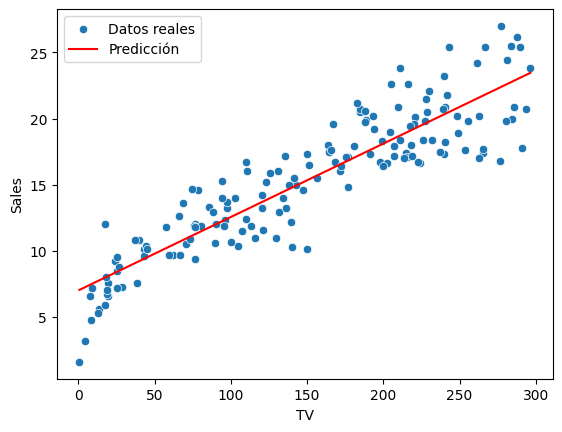

In [13]:
# Redimensiona el conjunto X de entrenamiento

X_train = X_train.reshape(-1, 1)
# Realiza la prediccion sobre el conjunto X de entrenamiento
y_pred_train = modelo.predict(X_train)
# Con seabor haz una grafica de dispersión para comparar los conjuntos
sns.scatterplot(x=X_train.flatten(), y=Y_train, label='Datos reales')
sns.lineplot(x=X_train.flatten(), y=y_pred_train, color='red', label='Predicción')

plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

## Evaluación del modelo

In [14]:
# Importa las métricas mean_squared_error y r2_score
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
# Haz la prediccion utilizando el conjunto de prueba

y_pred_test = modelo.predict(X_test)
#calculo el error caudratico medio  y R2
mse = mean_squared_error(Y_test, y_pred_test)
r2 = r2_score(Y_test, y_pred_test)

print('Error cuadrático (MSE)', mse)
print('R2', r2)

Error cuadrático (MSE) 6.101072906773963
R2 0.802561303423698


#### Contesta en esta misma celda: ¿Que deduces de las métricas anteriores, es confiable tu modelo?. 